<a href="https://colab.research.google.com/github/Nagasi77/PCVK-2025/blob/main/Modul7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

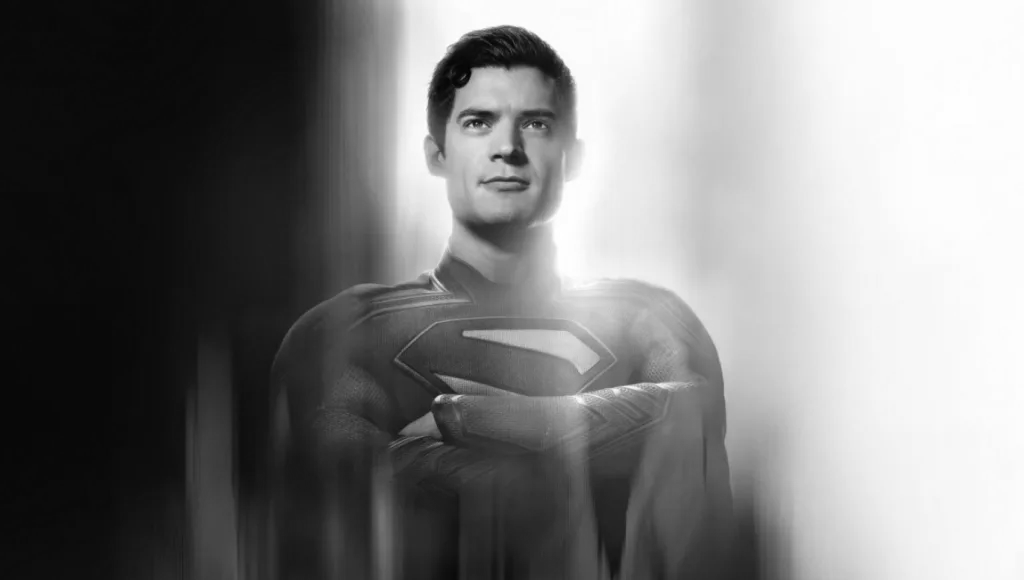

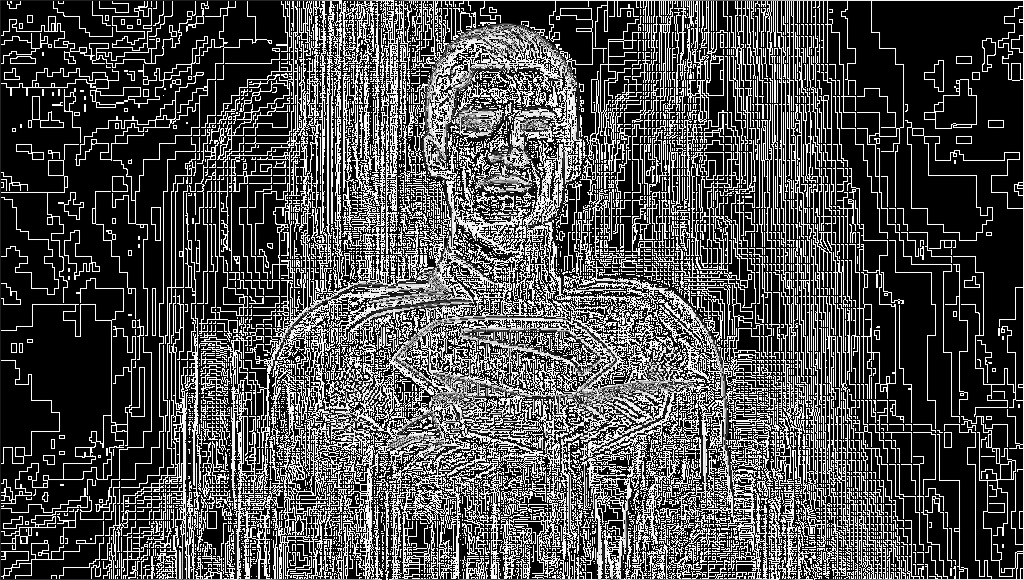

In [1]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

def convolution(image, kernel):
    # Ambil ukuran kernel
    k_height, k_width = kernel.shape
    pad_h = k_height // 2
    pad_w = k_width // 2

    # Padding pada citra agar ukuran tidak berkurang
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    # Buat output kosong
    output = np.zeros_like(image)

    # Looping tiap pixel
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Ambil region sesuai ukuran kernel
            region = padded_img[i:i+k_height, j:j+k_width]
            # Perkalian elemen-wise dan jumlahkan
            output[i, j] = np.sum(region * kernel)

    # Normalisasi supaya tetap dalam range 0-255
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

# Baca citra grayscale
img = cv.imread('/content/supes.webp', cv.IMREAD_GRAYSCALE)

# Kernel contoh: Deteksi tepi (Sobel)
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

# Terapkan konvolusi manual
result = convolution(img, kernel)

# Tampilkan hasil
cv2_imshow(img)
cv2_imshow(result)


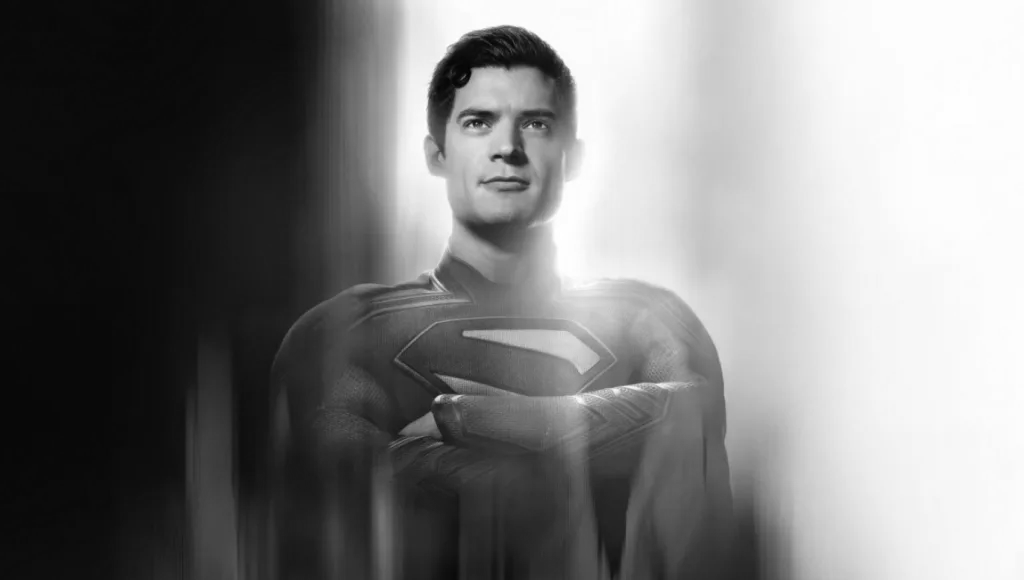

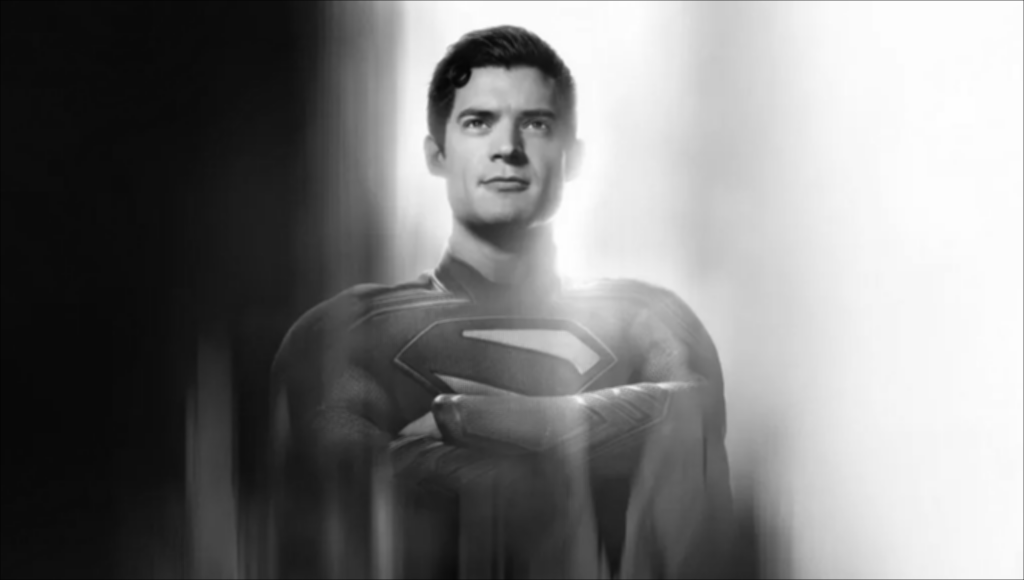

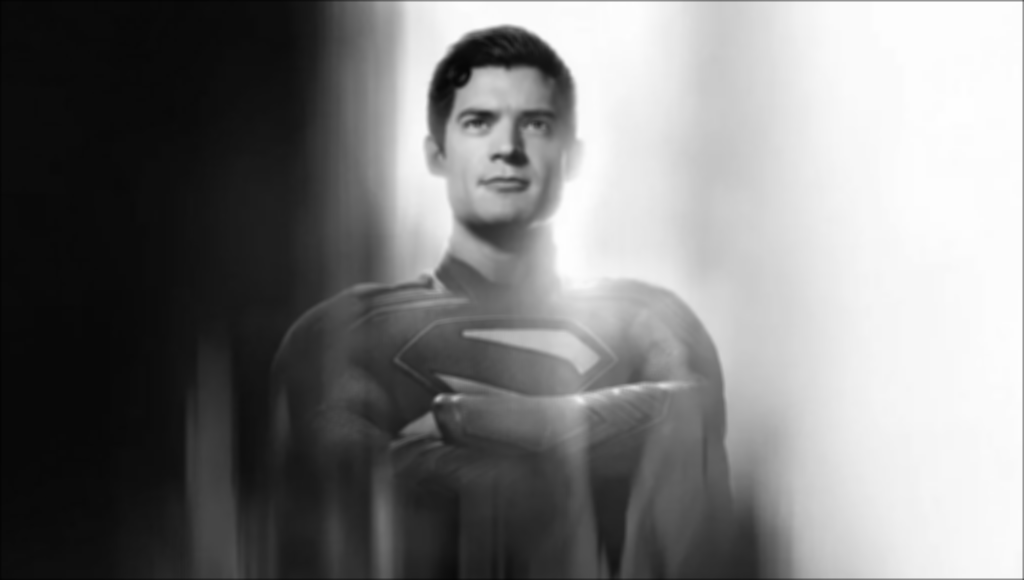

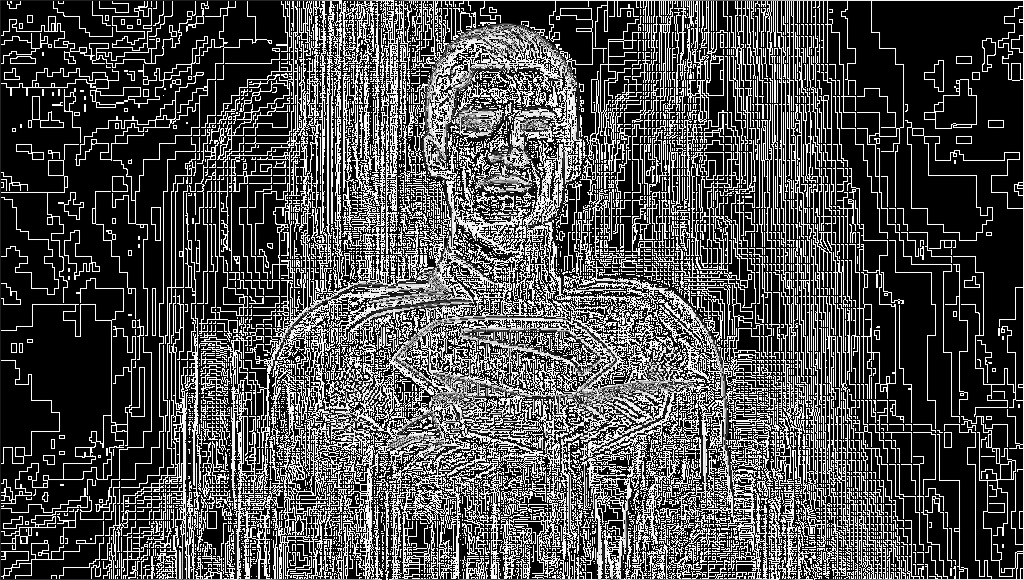

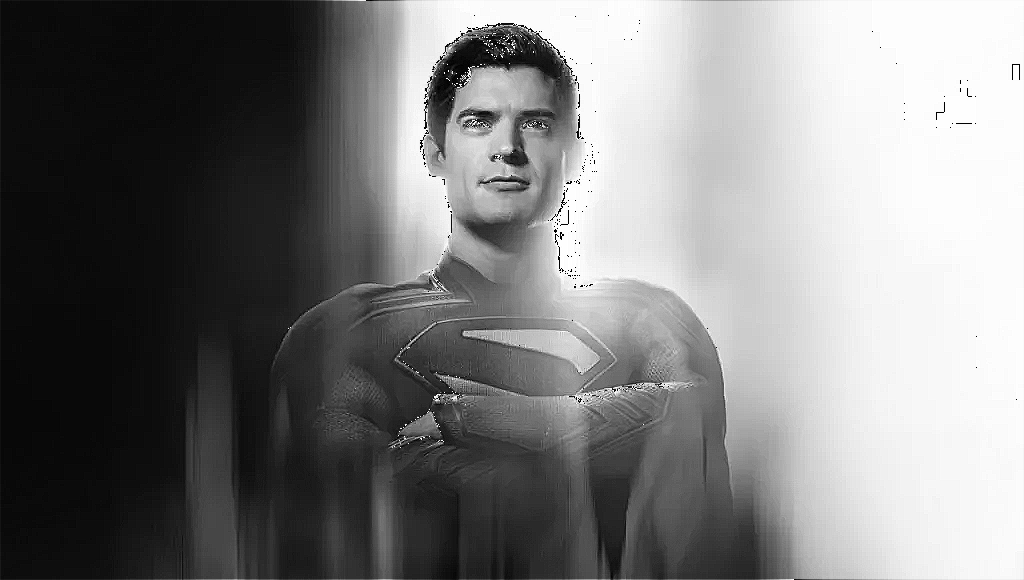

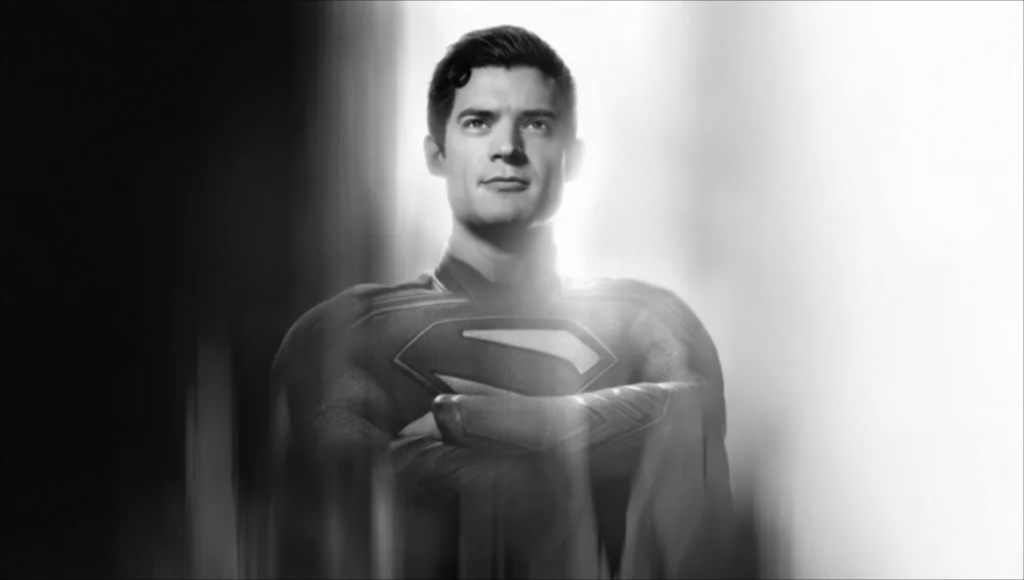

In [2]:
def convolution(image, kernel):
    k_height, k_width = kernel.shape
    pad_h, pad_w = k_height // 2, k_width // 2
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+k_height, j:j+k_width]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)


img = cv.imread('/content/supes.webp', cv.IMREAD_GRAYSCALE)

# 1. Average filter (blur)
kernel_avg = np.ones((3,3), np.float32) / 9

# 2. Low-pass filter (smoothing lebih kuat, misal 5x5)
kernel_low = np.ones((5,5), np.float32) / 25

# 3. High-pass filter (deteksi tepi)
kernel_high = np.array([[-1, -1, -1],
                        [-1,  8, -1],
                        [-1, -1, -1]])

# 4. Sharpen filter
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# 5. Gaussian-like filter (approx)
kernel_gauss = (1/16) * np.array([[1, 2, 1],
                                  [2, 4, 2],
                                  [1, 2, 1]])

# Terapkan filter
result_avg = convolution(img, kernel_avg)
result_low = convolution(img, kernel_low)
result_high = convolution(img, kernel_high)
result_sharp = convolution(img, kernel_sharpen)
result_gauss = convolution(img, kernel_gauss)

# Tampilkan hasil
cv2_imshow(img)
cv2_imshow(result_avg)
cv2_imshow(result_low)
cv2_imshow(result_high)
cv2_imshow(result_sharp)
cv2_imshow(result_gauss)
